# Setup e Importações

In [1]:
!pip install optuna scikit-learn seaborn matplotlib

import os
import gc
import time
import numpy as np
import tensorflow as tf
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import f1_score, classification_report

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, AdamW
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K

# Carregamento de Dados e Pesos

In [2]:
train_dir = '/kaggle/input/newdataset/new_dataset/train'
val_dir = '/kaggle/input/newdataset/new_dataset/val'
test_dir = '/kaggle/input/newdataset/new_dataset/test'

img_size = (224, 224)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# Treino (embaralhado)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size, label_mode='int', seed=123
)

class_names_geral = train_dataset.class_names

# Validação (SEM embaralhar)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
)

# Teste (SEM embaralhar) - Novo!
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
)

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

labels = np.concatenate([y for x, y in train_dataset], axis=0)
class_counts = Counter(labels)
total = sum(class_counts.values())

class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
print("Pesos das classes:", class_weights)

Found 1905 files belonging to 5 classes.
Found 408 files belonging to 5 classes.
Found 409 files belonging to 5 classes.
Pesos das classes: {3: 1.0793201133144477, 0: 2.1284916201117317, 2: 0.5489913544668588, 1: 0.9202898550724637, 4: 1.4377358490566037}


# Módulo de Data Pipeline

In [3]:
def get_augmentation_layer(trial=None, best_params=None):
    if trial:
        rot = trial.suggest_float("rotation", 0.0, 0.1)
        cont = trial.suggest_float("contrast", 0.0, 0.2)
        bright = trial.suggest_float("brightness", 0.0, 0.2)
        z_h = trial.suggest_float("zoom_height", -0.1, 0.1)
        z_w = trial.suggest_float("zoom_width", -0.1, 0.1)
        t_h = trial.suggest_float("translate_height", 0.0, 0.1)
        t_w = trial.suggest_float("translate_width", 0.0, 0.1)
    else:
        rot = best_params['rotation']
        cont = best_params['contrast']
        bright = best_params['brightness']
        z_h = best_params['zoom_height']
        z_w = best_params['zoom_width']
        t_h = best_params['translate_height']
        t_w = best_params['translate_width']

    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomTranslation(height_factor=t_h, width_factor=t_w),
        tf.keras.layers.RandomZoom(height_factor=(z_h, 0.1), width_factor=(z_w, 0.1)),
        tf.keras.layers.RandomRotation(rot),
        tf.keras.layers.RandomContrast(cont),
        tf.keras.layers.RandomBrightness(bright)
    ])

def apply_augmentation(dataset, aug_layer):
    return dataset.map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=AUTOTUNE)

# Construtor da Arquitetura do Modelo

In [ ]:
def create_model(trial, is_final=False, best_params=None):
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True) if trial else best_params['learning_rate']
    use_pre = trial.suggest_categorical("use_pretrained", [True, False]) if trial else best_params['use_pretrained']
    fine_t = trial.suggest_categorical("fine_tune", [True, False]) if trial else best_params['fine_tune']
    opt_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "AdamW", "SGD"]) if trial else best_params['optimizer']

    # Optuna decide a QUANTIDADE de camadas densas no topo (1 a 3)
    n_dense_layers = trial.suggest_int("n_dense_layers", 1, 3) if trial else best_params['n_dense_layers']

    # E também o tamanho/dropout de CADA camada de forma independente
    dense_units_per_layer = []
    dropout_per_layer = []
    for i in range(n_dense_layers):
        if trial:
            units_i = trial.suggest_int(f"dense_units_l{i}", 128, 1024, step=128)
            drop_i = trial.suggest_float(f"dropout_rate_l{i}", 0.2, 0.6)
        else:
            units_i = best_params[f"dense_units_l{i}"]
            drop_i = best_params[f"dropout_rate_l{i}"]
        dense_units_per_layer.append(units_i)
        dropout_per_layer.append(drop_i)

    weights_choice = 'imagenet' if use_pre else None
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False, weights=weights_choice, input_shape=(224, 224, 3), name='mobilenet_base'
    )

    ft_at = trial.suggest_int("fine_tune_at", 20, 140, step=20) if trial else best_params['fine_tune_at']

    if fine_t:
        base_model.trainable = True
        for layer in base_model.layers[:ft_at]:
            layer.trainable = False
    else:
        base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3), name='input_imagem')
    x = preprocess_input(inputs)
    x = base_model(x, training=fine_t)
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Empilha N blocos Dense -> BatchNorm -> Dropout, conforme decidido pelo Optuna
    for i, (units_i, drop_i) in enumerate(zip(dense_units_per_layer, dropout_per_layer)):
        x = tf.keras.layers.Dense(
            units_i,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'dense_features_l{i}'
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f'bn_l{i}')(x)
        x = tf.keras.layers.Dropout(drop_i, name=f'dropout_l{i}')(x)

    outputs = tf.keras.layers.Dense(5, activation='softmax', name='predicao_final')(x)

    model = tf.keras.Model(inputs, outputs)

    if opt_name == "Adam": optimizer = Adam(lr)
    elif opt_name == "RMSprop": optimizer = RMSprop(lr)
    elif opt_name == "AdamW": optimizer = AdamW(lr)
    else: optimizer = SGD(lr, momentum=0.9)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# Busca do Optuna

In [5]:
def objective(trial):
    K.clear_session()
    
    model = create_model(trial)
    aug_layer = get_augmentation_layer(trial=trial)
    train_dataset_aug = apply_augmentation(train_dataset, aug_layer)

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    model.fit(
        train_dataset_aug,
        validation_data=val_dataset,
        epochs=15,
        callbacks=[early_stop],
        verbose=0,
        class_weight=class_weights
    )

    y_true = np.concatenate([y for x, y in val_dataset], axis=0)
    y_pred_probs = model.predict(val_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=-1)
    
    f1_macro = f1_score(y_true, y_pred, average='macro')

    K.clear_session()
    gc.collect()
    
    return f1_macro


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
print("Melhores parâmetros:", study.best_params)

[I 2026-04-18 18:04:09,277] A new study created in memory with name: no-name-92289643-7f06-4fa9-9fc0-f9cf11db973a
[I 2026-04-18 18:06:40,204] Trial 0 finished with value: 0.1064748201438849 and parameters: {'learning_rate': 0.0001807827064656529, 'dense_units': 768, 'dropout_rate': 0.46094244955056746, 'use_pretrained': False, 'fine_tune': True, 'optimizer': 'RMSprop', 'fine_tune_at': 140, 'rotation': 0.03757885197972171, 'contrast': 0.05697394473747497, 'brightness': 0.04512786531834583, 'zoom_height': 0.014734504003414875, 'zoom_width': -0.07577333028379857, 'translate_height': 0.06546844112630834, 'translate_width': 0.056810582948332744}. Best is trial 0 with value: 0.1064748201438849.
[I 2026-04-18 18:09:49,474] Trial 1 finished with value: 0.1064748201438849 and parameters: {'learning_rate': 0.0005969005206179606, 'dense_units': 256, 'dropout_rate': 0.39701423123883617, 'use_pretrained': False, 'fine_tune': False, 'optimizer': 'Adam', 'fine_tune_at': 140, 'rotation': 0.08944537912

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[I 2026-04-18 18:18:04,547] Trial 3 finished with value: 0.9197402379305842 and parameters: {'learning_rate': 4.655689403217061e-05, 'dense_units': 512, 'dropout_rate': 0.2810172259010583, 'use_pretrained': True, 'fine_tune': True, 'optimizer': 'Adam', 'fine_tune_at': 140, 'rotation': 0.046101405872757045, 'contrast': 0.006804801627091673, 'brightness': 0.12817681785094487, 'zoom_height': 0.08382641261009366, 'zoom_width': -0.03258110628559567, 'translate_height': 0.05425594382482755, 'translate_width': 0.09995622853609971}. Best is trial 3 with value: 0.9197402379305842.
[I 2026-04-18 18:20:20,342] Trial 4 finished with value: 0.07162977867203218 and parameters: {'learning_rate': 7.488751364736703e-05, 'dense_units': 1024, 'dropout_rate': 0.4575496727314172, 'use_pretrained': False, 'fine_tune': True, 'optimizer': 'AdamW', 'fine_tune_at': 40, 'rotation': 0.07492960311077422, 'contrast': 0.17584001297927754, 'brightness': 0.1011661734219729, 'zoom_height': 0.07733769979613883, 'zoom_wi

Melhores parâmetros: {'learning_rate': 0.00038108575288890305, 'dense_units': 384, 'dropout_rate': 0.26715935880092323, 'use_pretrained': True, 'fine_tune': True, 'optimizer': 'Adam', 'fine_tune_at': 80, 'rotation': 0.07601029448497622, 'contrast': 0.08066971511096267, 'brightness': 0.08863158018891405, 'zoom_height': 0.007617154183141253, 'zoom_width': -0.011466715123054878, 'translate_height': 0.05916826948954462, 'translate_width': 0.038103918602790915}


# Treinamento Definitivo

In [6]:
best_params = study.best_params

model = create_model(trial=None, is_final=True, best_params=best_params)
aug_layer_final = get_augmentation_layer(best_params=best_params)
train_dataset_final = apply_augmentation(train_dataset, aug_layer_final)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

history = model.fit(
    train_dataset_final,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    class_weight=class_weights
)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 46s 401ms/step - accuracy: 0.7000 - loss: 0.9530 - val_accuracy: 0.5245 - val_loss: 1.5521 - learning_rate: 3.8109e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.9032 - loss: 0.3611 - val_accuracy: 0.6054 - val_loss: 1.9560 - learning_rate: 3.8109e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - accuracy: 0.9384 - loss: 0.2662 - val_accuracy: 0.7525 - val_loss: 1.5821 - learning_rate: 3.8109e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.9380 - loss: 0.2260 - val_accuracy: 0.7426 - val_loss: 2.2779 - learning_rate: 3.8109e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step - accuracy: 0.9689 - loss: 0.1547 - val_accuracy: 0.6912 - val_loss: 2.2154 - learning_rate: 3.8109e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 217ms/step - accuracy: 0.9483 - loss: 0.1802 - val_accuracy: 0.7010 - val_loss: 2.3803 - learning_rate: 3.8109e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/ste

# Avaliação Definitiva no Conjunto de Teste

In [7]:
print("Avaliando o modelo final no conjunto de TESTE (dados nunca vistos)...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

print(f"\nAcurácia no Teste: {test_acc:.4f}")
print(f"Perda no Teste: {test_loss:.4f}")

Avaliando o modelo final no conjunto de TESTE (dados nunca vistos)...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - accuracy: 0.9820 - loss: 0.1376

Acurácia no Teste: 0.9707
Perda no Teste: 0.1940


# Matriz de confusão e Avaliação Detalhada

Coletando rótulos reais do teste...
Gerando predições com o modelo final...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step


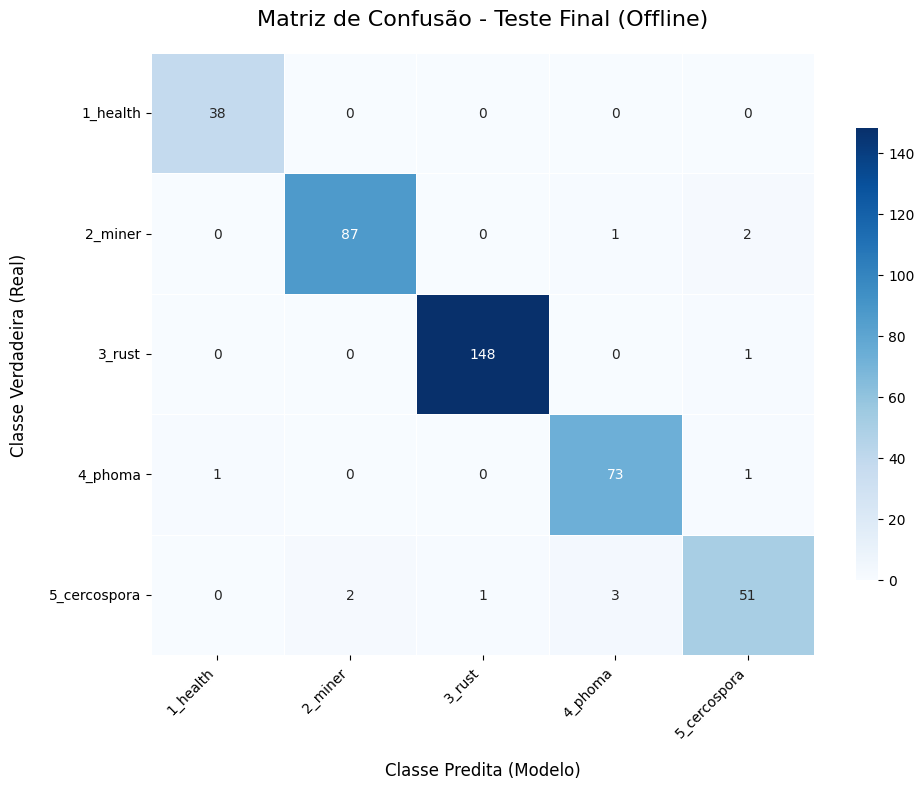


Relatório de Classificação Detalhado (Teste):

              precision    recall  f1-score   support

    1_health       0.97      1.00      0.99        38
     2_miner       0.98      0.97      0.97        90
      3_rust       0.99      0.99      0.99       149
     4_phoma       0.95      0.97      0.96        75
5_cercospora       0.93      0.89      0.91        57

    accuracy                           0.97       409
   macro avg       0.96      0.97      0.96       409
weighted avg       0.97      0.97      0.97       409



In [8]:
# CÉLULA: Matriz de Confusão no Conjunto de Teste
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Coletar os rótulos reais (Ground Truth) do dataset de teste
print("Coletando rótulos reais do teste...")
y_true_test = np.concatenate([y for x, y in test_dataset], axis=0)

# 2. Gerar as predições com o modelo treinado
print("Gerando predições com o modelo final...")
y_pred_probs_test = model.predict(test_dataset)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)

# 3. Calcular a Matriz de Confusão
cm = confusion_matrix(y_true_test, y_pred_test)

# 4. Plotar a Matriz graficamente com Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_geral, yticklabels=class_names_geral,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matriz de Confusão - Teste Final (Offline)', pad=20, fontsize=16)
plt.ylabel('Classe Verdadeira (Real)', fontsize=12, labelpad=15)
plt.xlabel('Classe Predita (Modelo)', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Relatório de Classificação (Precision, Recall e F1-Score por classe)
print("\nRelatório de Classificação Detalhado (Teste):\n")
print(classification_report(y_true_test, y_pred_test, target_names=class_names_geral))

# Estrutura Base para o Grad-CAM

In [9]:
# CÉLULA 10: Inteligência Artificial Explicável (Grad-CAM)
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Encontrar o índice exato onde a MobileNetV2 está inserida no seu modelo
    base_model_idx = model.layers.index(model.get_layer("mobilenet_base"))
    
    # 2. Executar as camadas iniciais (o pré-processamento) manualmente
    x = img_array
    for layer in model.layers[:base_model_idx]:
        # Ignoramos a InputLayer, pois ela é apenas um "placeholder"
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        x = layer(x)
        
    # 3. Resgatar o nosso extrator de características (A MobileNetV2)
    base_model = model.layers[base_model_idx]
    
    # 4. Abrir a gravação de gradientes do TensorFlow
    with tf.GradientTape() as tape:
        # Passamos a imagem pré-processada pelo modelo base
        # Como usamos include_top=False, a saída JÁ É o mapa de características convolucional final!
        feature_maps = base_model(x, training=False)
        
        # Dizer expressamente ao TensorFlow para monitorar essa variável
        tape.watch(feature_maps)
        
        # Continuar passando a imagem pelas camadas restantes (Pooling, Denses, Dropout)
        out = feature_maps
        for layer in model.layers[base_model_idx + 1:]:
            out = layer(out, training=False)
            
        preds = out
        
        # Isolar a predição da classe de interesse
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Calcular os gradientes da classe predita em relação aos mapas de características
    grads = tape.gradient(class_channel, feature_maps)

    # 6. Agrupar os gradientes (Tirando a média espacial - Global Average Pooling dos gradientes)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Multiplicar cada canal de característica pelo seu "peso" de importância (o gradiente)
    feature_maps = feature_maps[0]
    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Aplicar ReLU (remover valores negativos) e normalizar a imagem do calor entre 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.5):
    # Carregar imagem original
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Redimensionar o heatmap para o tamanho da imagem
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Converter o heatmap para cores (padrão Jet)
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Sobrepor as imagens
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    superimposed_img = jet_heatmap * alpha + (img.astype("float32") / 255)
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Visualizar
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagem Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM (Justificativa Visual)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predição: 3_rust (Confiança: 100.00%)


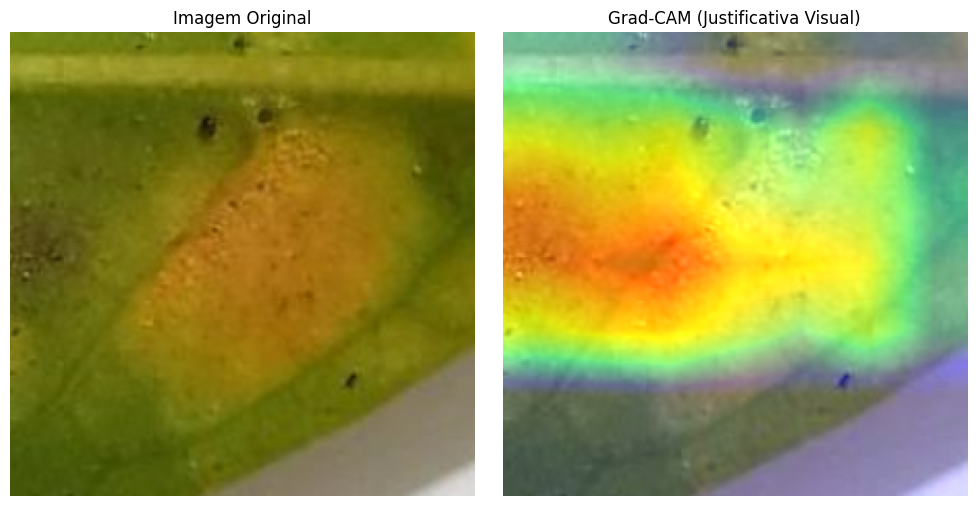

In [10]:
caminho_da_imagem = '/kaggle/input/newdataset/new_dataset/test/3_rust/1289_1366_0445_0208_0193.jpg'

# 1. Preparar a imagem para o modelo (batch de 1)
img_original = tf.keras.utils.load_img(caminho_da_imagem, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img_original)
img_array = np.expand_dims(img_array, axis=0)

# 2. Gerar Predição para saber o que o modelo achou que é
predicao = model.predict(img_array)
classe_predita = np.argmax(predicao[0])
confianca = np.max(predicao[0]) * 100

print(f"Predição: {class_names_geral[classe_predita]} (Confiança: {confianca:.2f}%)")

# 3. Gerar o Mapa de Calor e Mostrar
heatmap = make_gradcam_heatmap(img_array, model)
display_gradcam(caminho_da_imagem, heatmap)

# Exportador TensorFlow Lite para Flutter

In [11]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT] 

tflite_model = converter.convert()

with open('mobilenet_cafe_v1.tflite', 'wb') as f:
    f.write(tflite_model)
    
print("Modelo convertido para TFLite com sucesso! Pronto para integrar no aplicativo.")

Saved artifact at '/tmp/tmp_pfy6471'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_imagem')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133153756314992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677412720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677423984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677416944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677416592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677422928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677423808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677415888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141677409728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133141656995264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13314167741518